# Cosine Kernel Terms

We assumed any terms associated with the singular expression $$c^- = \frac{\cos(R(Z_1 -Z_2))}{Z_1 - Z_2}$$ did not contribute when picking out the Integral Coefficients.  Here we start to check if this is justified, both for particular choices of radiation mode normalization and in general.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.text import Text
from slab import SlabExact, plot_complex

%matplotlib widget
plt.style.use('dark_background')

# Form of term

For two class $\mathcal{A}$ radiation modes $u_\mathcal{A}(Z_1)$ and $u_\mathcal{A}(Z_2)$ defined by left coefficient vectors

$$v_1 = \begin{bmatrix}A_1 \\ B_1 \end{bmatrix} \qquad v_2 = \begin{bmatrix}A_2 \\ B_2 \end{bmatrix}$$ 

with associated right coefficient vectors

$$w_1 = \begin{bmatrix}C_1 \\ D_1 \end{bmatrix}  =  M(Z_1) v_1 \qquad w_2 = \begin{bmatrix}C_2 \\ D_2 \end{bmatrix} M(Z_2) v_2,$$ 

the expression in front of the cosine term ($c^-$) is given by

$$ (A_1 B_2 - B_1 A_2) - (C_1 D_2 - D_1 C_2).$$

Note that this is derived from the non-conjugated method of obtaining the integral coefficients.  Defining the matrix $$J = \begin{bmatrix} 0 & -1 \\ 1 & 0 \end{bmatrix}$$ the previous expression can be written as

$$v_2^T \left( J - M_2^T J M_1 \right) v_1.$$

Our interest lies in not this expression itself, but rather its properties when divided by $Z_1 - Z_2$, the latter term being pulled out of the denominator of $c^-$.  If this modified expression has sufficiently nice properties (as detailed in my dissertation), then the remaining portion of $c^-$, namely $\cos(R(Z_1 - Z_2))$, when integrated against the modified expression, will tend to zero as $R\rightarrow\infty$.

This is our hoped for scenario.  Underneath the hood, we are treating $Z_2$ as fixed and $Z_1$ as the variable of integration, so the hoped for properties of the modified expression are that it is $C^1$ as a function of $Z_1$ for any fixed value of $Z_2$.  Finally, there is in fact also the integral coefficient itself as part of the term, so we need to include it in the modified expression.  This latter element contains combinations of the coefficients in different ways as well, so it may change things a good deal.  Regardless, our first investigation will look at the matrix $v_2^T \left( J - M_2^T J M_1 \right) v_1$ and examine its properties.

In [2]:
A = SlabExact(symmetric=True)

In [3]:
def expr(Z, Z2=2, method='ours'):
    try:
        len(Z)
        Z = np.array(Z, dtype=complex)
    except TypeError:
        Z = np.array([Z], dtype=complex)
    
    J = np.zeros(Z.shape + (2, 2), dtype=np.complex128)
    J[..., 0, 1] = -1
    J[..., 1, 0] = 1

    Cs1 = A.coefficients(Z, Normalizer=A.normalizer(method), mode_type='radiation')
    Cs2 = A.coefficients(Z2, Normalizer=A.normalizer(method), mode_type='radiation')
    JCs1 = J @ Cs1
    return 1j * (((JCs1)[...,0][...,np.newaxis,:] @ Cs2[...,0][..., np.newaxis]) -  
                 ((JCs1)[...,-1][...,np.newaxis,:] @ Cs2[...,-1][..., np.newaxis]))[...,0,0] / (Z - Z2)


In [4]:
Z1s = np.linspace(.0001, 10, 150)
Z2s = np.linspace(1, 4, 4)
# Z2s = 2.4

Xs, Ys = np.meshgrid(Z1s, Z2s)

In [5]:
method = 'ours'
Fs = expr(Xs, Ys, method).T
# Fs[~np.isnan(Fs)]

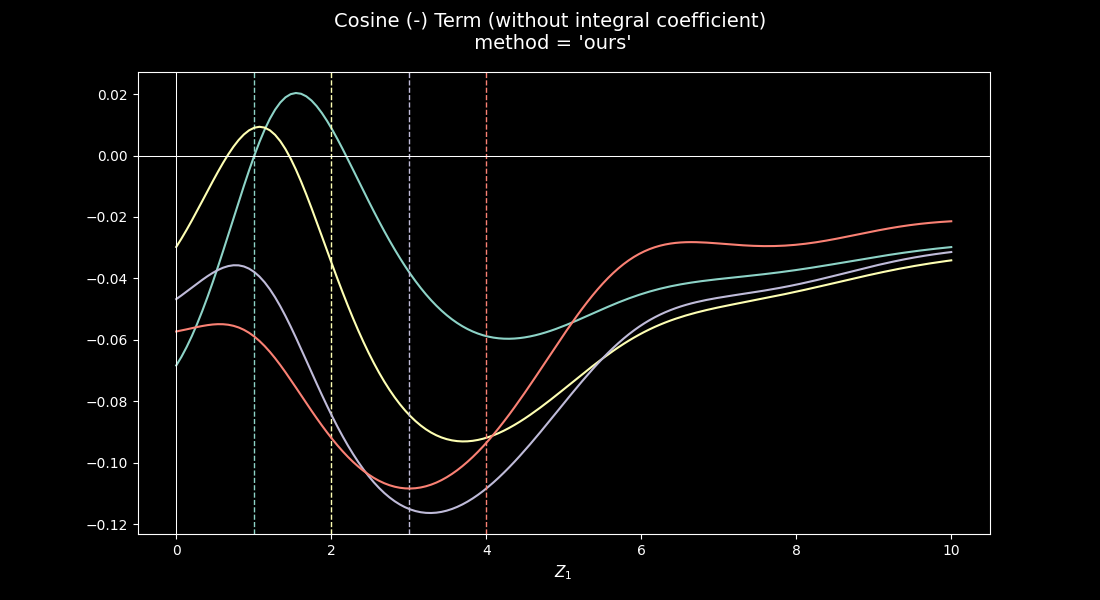

In [6]:
plt.close('all')
fig, ax = plt.subplots(1, figsize=(11,6))

for i in range(len(Z2s)):
    ax.plot(Z1s, Fs[:, i].real, color='C' + str(i))
    ax.axvline(Z2s[i], lw=1, ls='--', c= 'C' + str(i))
    
# ax.plot(Z1s, Fs.imag)
# ax.axvline(Z2s, lw=1, ls='--')
# ax.vlines(Z2s, *ax.get_ylim(), lw=1, ls='--')
ax.axhline(0, lw=.75)
ax.axvline(0, lw=.75)
# ax.set_xticks(list(ax.get_xticks()) + [Z2s])
# ax.set_xticklabels(ax.get_xticklabels()[:-1] + [Text(Z2s, 0, '\n$Z_2=%.2f$'%Z2s)])
fig.suptitle("Cosine (-) Term (without integral coefficient)\n method = '%s'\n"%method, fontsize=14)
ax.set_xlabel("$Z_1$", fontsize=11);
# plt.legend()

/tmp/ipykernel_80514/2634854634.py:15: RuntimeWarning: invalid value encountered in divide
  return 1j * (((JCs1)[...,0][...,np.newaxis,:] @ Cs2[...,0][..., np.newaxis]) -


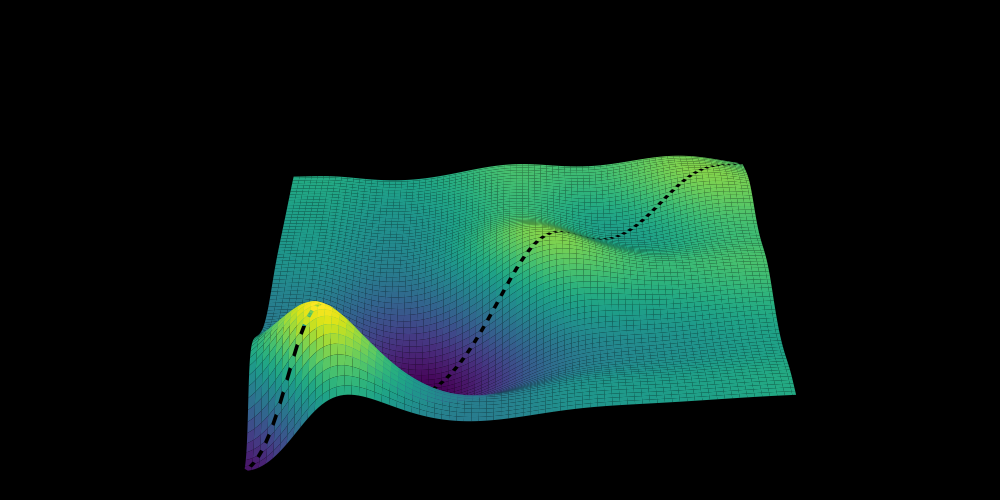

In [8]:
fig, ax = A.plot_field_2d_surface(expr, xs=Z1s, zs=Z1s, product_func=False, cstride=2,rstride=2,
                                 elev=25, azim=-90)